## Module 4: 

## Team Members:
Asma Sanaullah & Makayla Adams
## Project Title:
Comparing Growth Signaling in Glioblastoma Multiforme (GBM) and Lower Grade Glioma (LGG)


## Project Goal:

This project seeks to compare the genes in involved in the hallmark sustained proliferative growth signaling between Glioblastoma Multiforme (GBM) and Lower Grade Glioma (LGG), two brain tumors. GBM is a higher grade than LGG and since a higher grade implies a more aggressive form of cancer, we are interested to see if that leads to a difference in growth signaling between the two cancer types. We aim to do this by analyzing the gene expression of signaling genes to determine how sustained proliferative signaling drives the aggressive growth and progression of these two brain cancers. 

## Disease Background:

* Cancer Hallmark Focus: “Sustains Proliferative Signaling” 

* Overview of Hallmark: Cancer cells achieve the hallmark of sustained proliferative signaling by bypassing normal growth factor requirements through three main mechanisms: producing their own growth factors to create a self stimulating autocrime loop, mutating transmembrane receptors to remain permanently active, and hijacking internal signaling pathways to keep the cell in a state of continuous division. 

* Genes Associated with the Target Hallmark: MKI67, AKT1, EGFR, CDK1, CDK2, AURKA, AURKB

* Prevalence & incidence

Glioblastoma Multiforme (GBM) is the most aggressive and frequently diagnosed malignant brain tumor in adults, representing nearly half of all such cases. With an annual incidence of approximately 3.2 to 4.2 per 100,000 people in the US, it predominantly affects older adults, with a median diagnosis of age 64. In contrast, Lower Grade Gliomas (LGG) are less common and typically strike a younger demographic, often surfacing in patients in their 30’s and 40’s. While LGGs follow a slower initial trajectory, the clinical reality of GBM is that it carries a median survival of only 14 to 15 months, emphasizing the urgent need for effective interventions. 

* Risk factors (genetic, lifestyle) & Societal determinants

The development of these types of tumors is largely sporadic, though rare hereditary conditions like Neurofibromatosis significantly elevate an individual's risk. Beyond genetics, ionizing radiation to the head is the only confirmed environmental trigger. Biological risks are compounded by complex societal determinants. Higher socioeconomic status is linked to higher reported incidence (likely due to superior diagnosis access), whereas patients from lower income or rural background face much harsher outcomes. These disparities often stem from delayed starts in radiotherapy and limited access to specialized neuro-oncology centers required for the complex care. 

* Standard of care treatments (& reimbursement) 

The clinical treatment of GBM centers on the “Stupp Protocol” which begins with maximal safe surgical tissue removal followed by a combination of radiation and chemotherapy. Modern additions to this therapy include Tumor Treating Fields (TTFields) which is a wearable device that targets cancerous cells with an electrical field. For LGG, the approach to treatment has more nuances, ranging from monitoring to early aggressive surgeries. 
However, these treatments come at a staggering financial cost, in the US, the first 6 months of GBM care can exceed $150,000. These price tags often lead to patients not being able to access these treatments, especially the newer technologies.  

* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology)

At the cellular level, gliomas are defined by their "diffusely infiltrative" nature, where tumor cells migrate along white matter tracts and blood vessels, making total surgical elimination nearly impossible. This invasiveness is fueled by the overactivation of growth signaling pathways, including EGFR and PI3K, which drive rapid proliferation. Furthermore, GBMs secrete VEGF (vaso endothelial growth factor) to stimulate the growth of new, leaky blood vessels and "re-educate" local immune cells to protect the tumor rather than attack it. These mechanisms are anchored by a resilient population of glioma stem cells that effectively avoid standard radiation and chemotherapy, serving as the primary engine for the nearly inevitable recurrence of the disease.

## Data-Set: 


The subset of data we will analyze in this project focuses on two types of brain tumors, Glioblastoma Multiforme and Brain Lower Grade Glioma, each with 80 samples. The goal here is to compare high and low grade gliomas by looking at the sustaining growth signaling hallmark to see how these signaling pathways and uncontrolled growth differ and how gene expression can relate. We subsetted the data to only conclude these two cancers and we selected relevant genes present in the data, including MKI67, AKT1, EGFR, CDK1, CDK2, AURKA and AURKB. These genes are associated with cell proliferation and growth signaling pathways. We confirmed that these genes were present in the data and based on our exploratory data analysis. We won’t be looking at clinical features right now as we simply want to focus on the difference in how genes are expressed. 

This dataset comes from the paper, Alternative preprocessing of RNA-Sequencing data in The Cancer Genome Atlas leads to improved analysis results. Here researchers used The Cancer Genome Atlas (TCGA) RNA-sequencing data and reprocessed it to make gene expression measurements more consistent and usable for analysis. RNA sequencing measures gene expression throughmRNA transcripts which shows how much a gene is active. Researchers made it easier to compare “gene-level expression values across samples” which is useful for our project goal. RNA seq can be interpreted by the data normalization method TPM (transcripts per million) which is used to account for sequencing depth and length. The gene expression here was calculated as log2 transformed to reduce chances of skewed data. It also allows for a more direct comparison of gene expression levels fairly. 

https://pubmed.ncbi.nlm.nih.gov/26209429/ 



#### Subsetting & Cleaning the Data for Cancer Types & Genes

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:


# this code block loads the data and prints the shape and info of the training data + metadata

# Load the data
data = pd.read_csv(
    '../Data/TRAINING_SET_GSE62944_subsample_log2TPM.csv',
    index_col=0
)

# Load the metadata
metadata_df = pd.read_csv(
    '../Data/TRAINING_SET_GSE62944_metadata.csv',
    index_col=0
)

# load the gene data
gene_data = pd.read_table(
    r'C:\Users\Asma Sanaullah\OneDrive - University of Virginia\Spring 2026\COMP BME\Module-4-Cancer\data\Menyhart_JPA_CancerHallmarks_core.txt'
)

print(data.shape)
print(metadata_df.info())


#%%

# this code block extracts the specific genes we want to use for the cancer hallmark proliferative signaling

desired_gene_list = gene_data.iloc[7].tolist() #proliferative signaling genes in the gene data
gene_list = [g for g in desired_gene_list if g in data.index] # filter to only include genes present in the data

print("Proliferative Signaling Genes:", len(gene_list)) 


(15716, 1802)
<class 'pandas.core.frame.DataFrame'>
Index: 1802 entries, TCGA-E9-A1NI-01A-11R-A14D-07 to TCGA-ND-A4WC-01A-21R-A28V-07
Data columns (total 29 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   cancer_type                          1802 non-null   object 
 1   bcr_patient_barcode                  1730 non-null   object 
 2   gender                               1730 non-null   object 
 3   race                                 1730 non-null   object 
 4   ethnicity                            1730 non-null   object 
 5   age_at_diagnosis                     1730 non-null   object 
 6   ajcc_pathologic_tumor_stage          1144 non-null   object 
 7   ajcc_nodes_pathologic_pn             1142 non-null   object 
 8   ajcc_metastasis_pathologic_pm        1142 non-null   object 
 9   ajcc_tumor_pathologic_pt             1142 non-null   object 
 10  tumor_status                        

#### Exploratory Analysis with Data

In [7]:
# this code block creates a subset of the data for just GBM and LGG samples, then merges it with the metadata for those samples

cancer_types = ["GBM", "LGG"] # 2 specific cancer types GBM & LGG

cancer_samples = metadata_df[
    metadata_df["cancer_type"].isin(cancer_types)
].index

subset_data_2c = data[cancer_samples] # subset the data to only include the samples of interest (GBM and LGG)
subset_gene_data_2c = subset_data_2c.loc[gene_list] # subset the data to only include the genes of interest (proliferative signaling genes)

merged_2c = subset_gene_data_2c.T.merge(
    metadata_df.loc[cancer_samples],
    left_index=True,
    right_index=True
)

print("2-class shape:", merged_2c.shape)

2-class shape: (160, 635)


       TCGA-HT-8011-01A-11R-2403-07  TCGA-RY-A83Y-01A-11R-A36H-07  \
count                    606.000000                    606.000000   
mean                       4.149007                      3.803611   
std                        2.407034                      2.359871   
min                        0.000000                      0.000000   
25%                        2.292041                      1.976826   
50%                        4.333520                      4.010255   
75%                        5.816882                      5.368674   
max                       12.764617                     12.571159   

       TCGA-HT-7616-01A-11R-2256-07  TCGA-P5-A737-01A-11R-A32Q-07  \
count                    606.000000                    606.000000   
mean                       4.433080                      4.036227   
std                        2.245537                      2.381186   
min                        0.000000                      0.000000   
25%                        3.0267

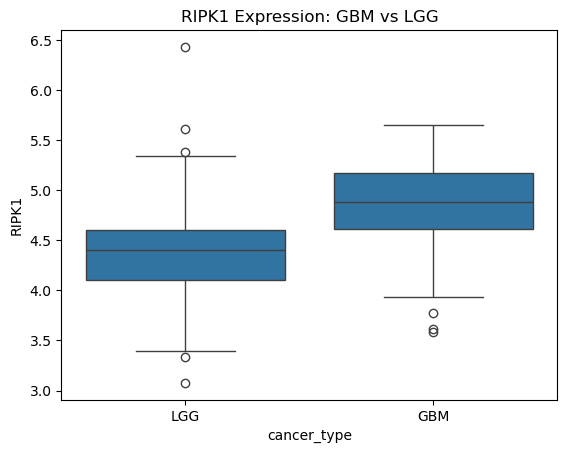

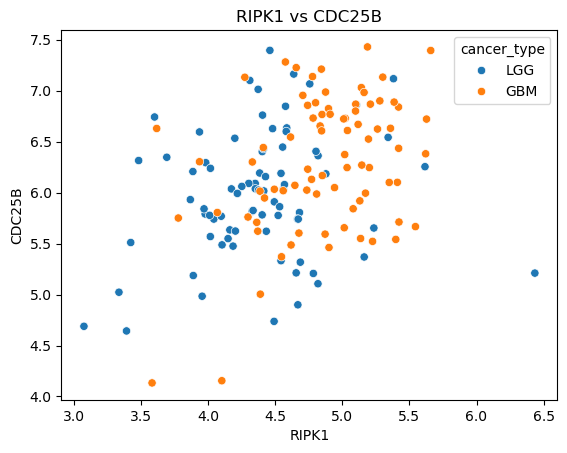

In [9]:
#%%

# this code block performs some basic exploratory data analysis on the subsetted data for GBM and LGG samples, including summary statistics 

print(subset_gene_data_2c.describe())

print("Variance per gene:")
print(subset_gene_data_2c.var(axis=1))

print("Mean per gene:")
print(subset_gene_data_2c.mean(axis=1))

print(metadata_df.groupby('cancer_type')["gender"].value_counts())


#%%

# this code block calculates the average expression of each gene in the gene list for GBM and LGG samples, and prints the results

GBM_ids = metadata_df[metadata_df['cancer_type'] == 'GBM'].index
LGG_ids = metadata_df[metadata_df['cancer_type'] == 'LGG'].index

for gene in gene_list:
    print(
        f"{gene}: GBM={data.loc[gene, GBM_ids].mean():.2f}, "
        f"LGG={data.loc[gene, LGG_ids].mean():.2f}"
    )


#%%%


sns.boxplot(data=merged_2c, x="cancer_type", y='RIPK1') # this creates a boxplot comparing the expression of the gene RIPK1 between GBM and LGG samples
plt.title("RIPK1 Expression: GBM vs LGG")
plt.show()

sns.scatterplot(data=merged_2c, x="RIPK1", y="CDC25B", hue="cancer_type") # this creates a scatterplot comparing the expression of the gene RIPK1 vs CDC25B, colored by cancer type (GBM vs LGG)
plt.title("RIPK1 vs CDC25B")
plt.show()

#### Results from Exploratory Analysis

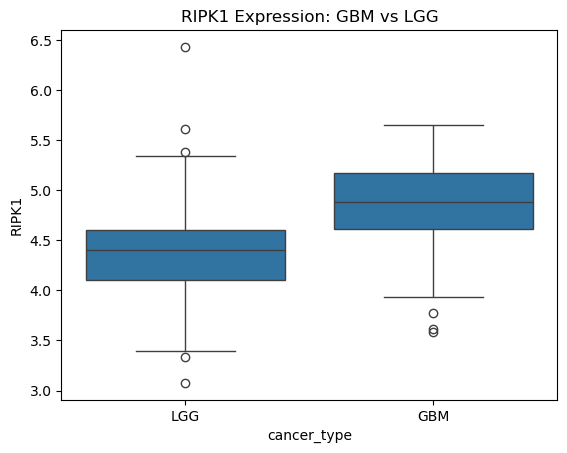

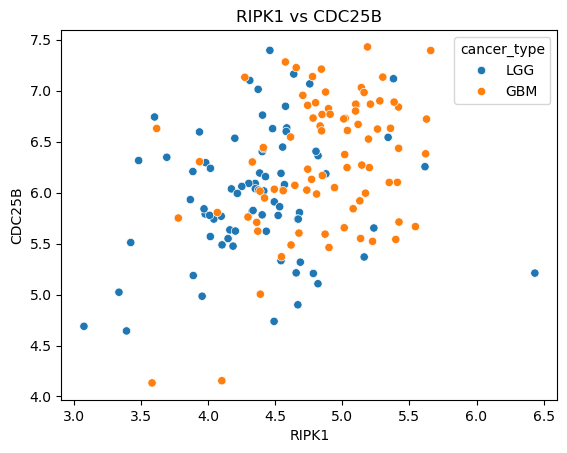

#### Exploring the Data PCA

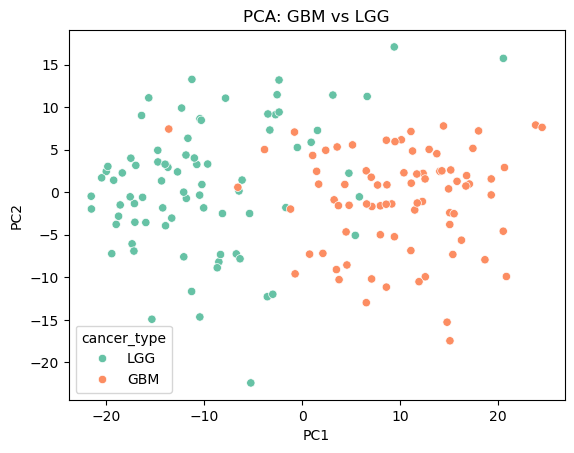

In [5]:
#import needed libraries 
from sklearn.decomposition import PCA

# this code block performs PCA on the subsetted data for GBM and LGG samples, and visualizes the results in a scatterplot colored by cancer type

X_2c = merged_2c[gene_list]

pca = PCA(n_components=2) # this initializes a PCA object to reduce the dimensionality of the data to 2 principal components
X_pca = pca.fit_transform(X_2c) # this fits the PCA model to the data and transforms it into the PCA space

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=merged_2c["cancer_type"],
    palette="Set2"
)

plt.title("PCA: GBM vs LGG")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

#### PCA Results
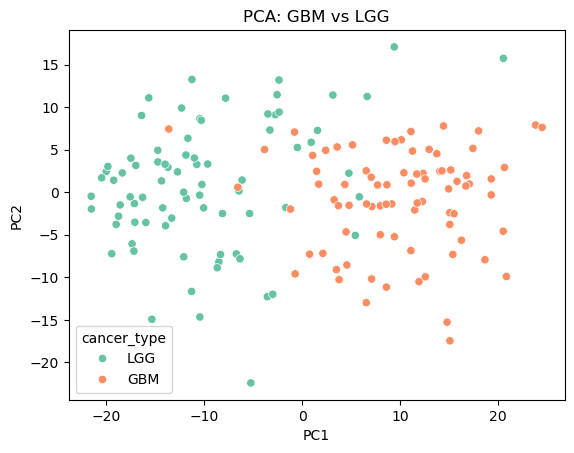

This plot shows that there is some separation between LGG and GBM cancer types, indicating that their gene expressions are different. Since there is separation amongst the two along the principal component 1 axis, these cancer types display distinct gene expression patterns associated with the hallmark sustained proliferative signaling. This aligns with the biology behind the cancers as GBM is a higher grade than LGG, which makes sense that GBM is further to the right with higher gene expression. It's importnt to note that some gene expressions for LGG indicate the cancer samples to be on the GBM side, so there isn't complete separation. 

#### K-MEANS Clustering on Data

c:\Users\Asma Sanaullah\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


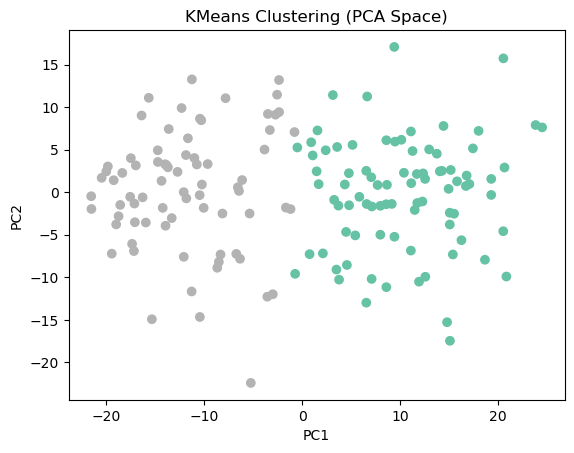

In [6]:
from sklearn.cluster import KMeans

# this code block performs KMeans clustering on the PCA-transformed data, and visualizes the results in a scatterplot colored by cluster/cancer type

kmeans = KMeans(n_clusters=2, random_state=0) # this performs clustering with 2 clusters (GBM and LGG) 
clusters = kmeans.fit_predict(X_pca) # this fits the KMeans model to the PCA-transformed data and assigns cluster labels to each sample

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap="Set2")
plt.title("KMeans Clustering (PCA Space)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

#### Results of Clustering
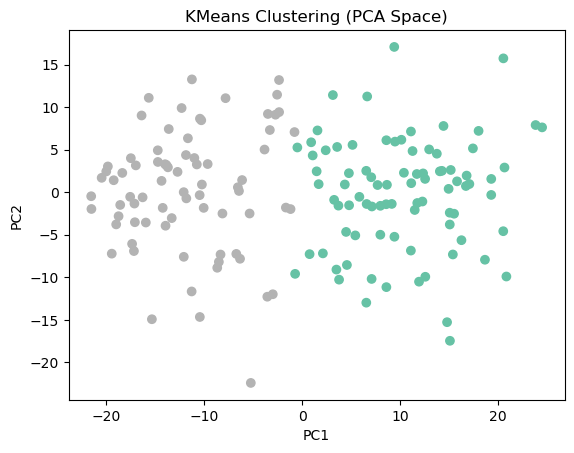

This displays two clear clusters that match cancer type between GBM (green) and LGG. This indicates strong signals that identify the grade of cancer and shows proliferative signaling can distinguish the two.

## Data Analysis: 

### Methods

The machine learning technique we are using is Classification. This is a supervised ML model that helps predict categorical labels so it categorizes data into distinct groups. This is relevant to our project goal because we are looking to see if gene expression patterns of the hallmark "sustained proliferative signaling" can be used to dstinguish GBM and LGG cancer types. Essentially, based on gene expression we want to determine whether the cancer type if GBM or LGG. 

This classification method is optimizing model parameters to minimize classification errors as the goal is to input data into predefined labels (GBM & LGG) to maximize accuracy. 

One type of classification model we can use is Logistical Regression which can predict the probability of GBM or LGG based on input features which here are gene expression values for each cancer sample. Logistic Regression is used for binary types of problems and it optimizes model coefficients to minimize prediction error and maximize correct cancer type probabilities. This is a good first choice because this model performs well when classes are separated and here there are as we have seen with k-means where GBM and LGG are distinct. This is a binary problem because we want to categorize the data into the two cancer types. 


This model decides it is good enough based on if it's able to minimize the difference between the predicted probabilities and the real outcomes. This includes maximum likelihood estimation which is a type of statistical method that finds the best-fitting parameter values for a model based on observed data. We can also evaluate if the fit is good by using metrics in Python like Log-likelihood and deviance. 

**

### Analysis


#### Fitting the Model

Since we are using the classification method, our model will be Linear Regression.

In [13]:
#Fitting the model to the data 
from sklearn.linear_model import LogisticRegression

# fitting logistic regression model to the training data for (GBM vs LGG
logreg_model_2c = LogisticRegression(
    penalty=None,
    max_iter=1000,
    multi_class="multinomial"
)
logreg_model_2c.fit(X_2c, merged_2c["cancer_type"])


c:\Users\Asma Sanaullah\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'multinomial'


#### Predicting the Target Variable

Our target variable is labeling whether the cancer type is GBM, LGG or neither. 
It's important to note here that we had to expand from a binary classifier (GBM or LGG) to a multiclass classifier (GBM, LGG and Neither). This is because the validation dataset had no GBM samples so we wouldn't be able to properly assess the data. Therefore, for our predicting models we kept 3 classes while for the exploratory analysis above we kept 2 classes as this mostly dealt with the training data. 

By includng the "Neither" class, we are able to expand our project goal by not only attempting to predict if a cancer type is LGG or GBM but also if the cancer a non-glioma one. The Neither class was added to test whether the model could first recognize samples that do not belong to either glioma subtype, improving specificity and making predictions more realistic.

In [14]:
# this code block creates a new class label in the metadata for a 3-class classification problem (GBM, LGG, Neither), then merges the full gene data with the metadata for all samples

# create a new class label that categorizes samples as GBM, LGG, or Neither (for samples that are not GBM or LGG - non glioma)
metadata_df["class_label"] = metadata_df["cancer_type"].apply(
    lambda x: x if x in ["GBM", "LGG"] else "Neither"
)

subset_all = data[metadata_df.index]
subset_gene_all = subset_all.loc[gene_list]

merged_3c = subset_gene_all.T.merge(
    metadata_df,
    left_index=True,
    right_index=True
)

X_train = merged_3c[gene_list] # this creates the feature matrix X for training data, which consists of the expression values of the genes in the gene list
y_train = merged_3c["class_label"] # this creates the target vector y for training data, which consists of the class labels (GBM, LGG, Neither) for each sample

print("3-class training shape:", X_train.shape)

3-class training shape: (1802, 606)


In [15]:
# this code block loads the validation data and metadata, creates the same 3-class label for the validation metadata, subsets the validation data to just the genes in the gene list

validation_data = pd.read_csv(
    r'C:\Users\Asma Sanaullah\OneDrive - University of Virginia\Spring 2026\COMP BME\Module-4-Cancer\data\VALIDATION_SET_GSE62944_subsample_log2TPM.csv',
    index_col=0
)

validation_metadata = pd.read_csv(
    r'C:\Users\Asma Sanaullah\OneDrive - University of Virginia\Spring 2026\COMP BME\Module-4-Cancer\data\VALIDATION_SET_GSE62944_metadata.csv',
    index_col=0
)

validation_metadata["class_label"] = validation_metadata["cancer_type"].apply(
    lambda x: x if x in ["GBM", "LGG"] else "Neither"
)

val_subset = validation_data[validation_metadata.index]
val_gene = val_subset.loc[gene_list]

val_merged = val_gene.T.merge(
    validation_metadata,
    left_index=True,
    right_index=True
)

X_valid = val_merged[gene_list] # this creates the feature matrix X for validation data, which consists of the expression values of the genes in the gene list
y_valid = val_merged["class_label"] # this creates the target vector y for validation data, which consists of the class labels (GBM, LGG, Neither) for each sample


In [16]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# logistric regression model with multinomial option for multi-class classification
model_base = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        penalty=None,
        max_iter=2000,
        class_weight="balanced",
        multi_class="multinomial"
    )
)
model_base.fit(X_train, y_train)
y_pred_base = model_base.predict(X_valid)
print("Base Model Accuracy:", model_base.score(X_valid, y_valid))

Base Model Accuracy: 0.9955882352941177


c:\Users\Asma Sanaullah\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


#### Accuracy of Model on Validation Dataset
Base Model Validation Accuracy: 0.9955882352941177

## Verify and validate your analysis: 
*Pick a SPECIFIC metric to determine how well your model is performing and describe how it works here.*

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*


#### Metric to Test Model Performance
The metric we chose is a confusion matrix because this would allow us to see how our model correctly or incorrectly made predictions. This matrix shows where a model may have misclassified labels like false positive. Since we have a mutliclassifier model, a confusion matrix can show whether a cancer type was correctly labeled LGG, GBM or neither. 

A confusion matrix is essentially a table that analyzes the performance of our logistic regression mmodel because it compares true labels with predicted ones, showing where a model may have been confused. 

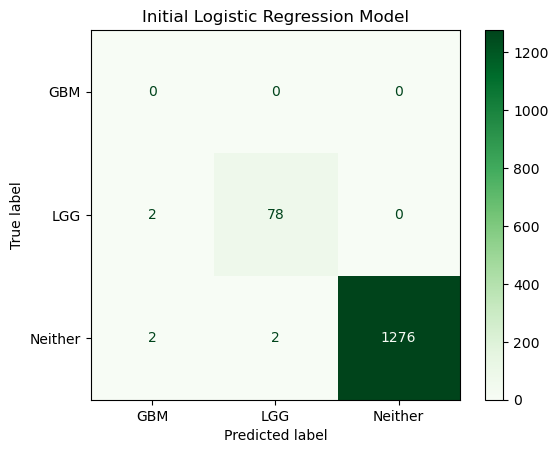

In [18]:
#confusion matrix to determine if model performs well on validation dataset 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# create confusion matrix for 3 classes: GBM, LGG and Neither

cm = confusion_matrix(y_valid, y_pred_base, labels=["GBM","LGG","Neither"]) # this computes the confusion matrix comparing the true labels (y_valid) to the predicted labels (y_pred_base), with the specified class order

ConfusionMatrixDisplay(cm, display_labels=["GBM","LGG","Neither"]).plot(cmap = "Greens")
plt.title("Initial Logistic Regression Model")
plt.show()


#### Confusion Matrix 

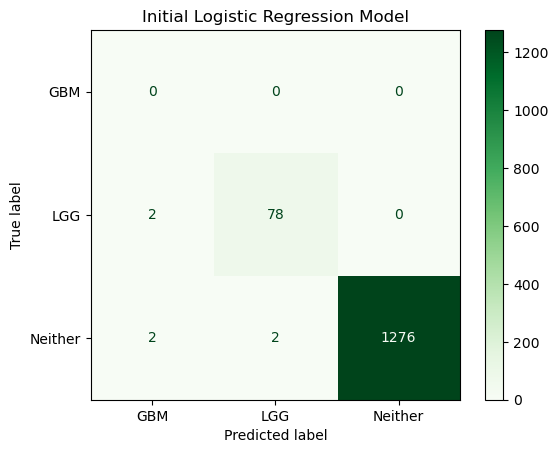

In this matrix, we can see that there are no true labels for GBM as GBM is not present in the validation dataset. Therefore, we cannot directly evaluate if GBM cancers are labeled accurately. 

Our validation dataset had 80 samples for LGG (80 true labeled samples). As we can see in the matrix, 78 were correctly predicted/labeled as LGG while 2 were incorrectly mislabeled as GBM. Our LGG accuracy is about 97.5%. 

Then for the rest of cancer samples (neither LGG or GBM), there were 1280 samples (1280 true labeled samples). 1276 were correctly predicted and labeled as neither while 2 were mislabeled for both GBM and LGG. 

#### In and Out of Sample Error

In sample error shows how well our models fits known data (training). Out of sample error shows us how well the model performs on data it hasn't seen before (validation).

In [19]:
from sklearn.metrics import accuracy_score

# In-sample performance (training set)

# Calculate training accuracy and error

# calculating in and out of sample error for training and validation sets for the initial logistic regression model
y_pred_train = model_base.predict(X_train)
train_acc = accuracy_score(y_train, y_pred_train)
# finding the in-sample error (training accuracy) and out-of-sample error (validation accuracy) for the initial logistic regression model, and printing the results
in_sample_error = 1 - train_acc
print(f"Training Accuracy: {train_acc:.4f}")
print(f"In-Sample Error (Training Accuracy): {in_sample_error:.4f}")

# Out-of-sample performance (validation set)

# Calculate validation accuracy and error
y_pred_valid = model_base.predict(X_valid)
valid_acc = accuracy_score(y_valid, y_pred_valid)
# finding the in-sample error (training accuracy) and out-of-sample error (validation accuracy) for the initial logistic regression model, and printing the results
out_of_sample_error = 1 - valid_acc
print(f"Validation Accuracy: {valid_acc:.4f}")
print(f"Out-of-Sample Error (Validation Accuracy): {out_of_sample_error:.4f}")



Training Accuracy: 1.0000
In-Sample Error (Training Accuracy): 0.0000
Validation Accuracy: 0.9956
Out-of-Sample Error (Validation Accuracy): 0.0044


#### Error Results

##### Training Accuracy: 1.0

Our model correctly classified 100% of training samples.

##### In-Sample Error: 0.0

We had no error on our training data so the model fits this data perfectly. 

##### Validation Accuracy: 0.9956

The model correctly classified 99.56% of the unseen cancer samples from the validation dataset.

##### Out-of-Sample Error: 0.0044

About 0.44% of validation samples were misclassified which is a low error. 

Here we are able to see that there is a strong difference in predicting LGG and neither cancer samples based on proliferative signaling genes. So we were able to see that the model classified glioma vs non-glioma cancer types. But because the validation dataset lacked GBM samples, we can't definitively say anything about the accuracy of classifying GBM cancers. 

#### Model Fit
Based on our low errors for the training and validation data, we find that our model is performing well overall. Note that since the validation dataset was dominated by LGG and neither labels, its performance may not be equally represented for all classes as GBM labels were missing. 

### Improving the Model

To improve the model, we added regularization terms to the logistic regression model. These terms prevent overfitting by adding a pentalty term to the cost function. We chose L1 Lasso Regularization (fewer coefficients) and L2 Ridge Regularization (decrease coefficients)

c:\Users\Asma Sanaullah\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


L1 Accuracy: 0.9992647058823529


c:\Users\Asma Sanaullah\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


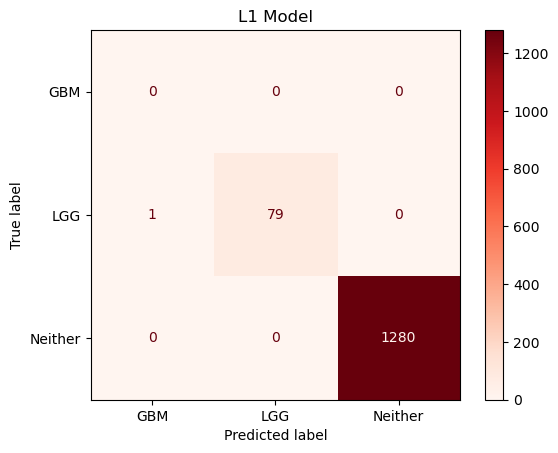

In [21]:
# this code block creates a logistic regression model with L1 regularization, fits it to the training data, evaluates its accuracy on the validation set
model_l1 = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        penalty="l1",
        solver="saga",
        max_iter=2000,
        class_weight="balanced",
        multi_class="multinomial"
    )
)

model_l1.fit(X_train, y_train)

y_pred_l1 = model_l1.predict(X_valid)

print("L1 Accuracy:", model_l1.score(X_valid, y_valid))


#%%

# this code block creates a confusion matrix for the L1 regularized logistic regression model

cm = confusion_matrix(y_valid, y_pred_l1, labels=["GBM","LGG","Neither"])

ConfusionMatrixDisplay(cm, display_labels=["GBM","LGG","Neither"]).plot(cmap="Reds")
plt.title("L1 Model")
plt.show()

c:\Users\Asma Sanaullah\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


L2 Accuracy: 0.9970588235294118


c:\Users\Asma Sanaullah\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


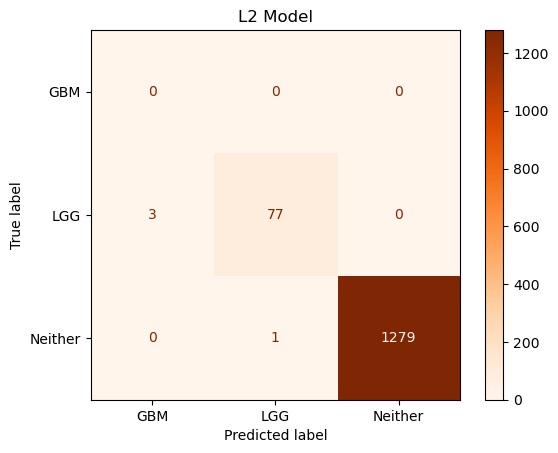

In [23]:
# this code block creates a logistic regression model with L2 regularization, fits it to the training data, evaluates its accuracy on the validation set

model_l2 = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        penalty="l2",
        solver="saga",
        max_iter=2000,
        class_weight="balanced",
        multi_class="multinomial"
    )
)

model_l2.fit(X_train, y_train)

y_pred_l2 = model_l2.predict(X_valid)

print("L2 Accuracy:", model_l2.score(X_valid, y_valid))

#%%

# this code block creates a confusion matrix for the L2 regularized logistic regression model

cm = confusion_matrix(y_valid, y_pred_l2, labels=["GBM","LGG","Neither"])

ConfusionMatrixDisplay(cm, display_labels=["GBM","LGG","Neither"]).plot(cmap="Oranges")
plt.title("L2 Model")
plt.show()

#### Confusion Matrix and Model Performance

| L1 | L2 | 
| -------- | -------- | 
| 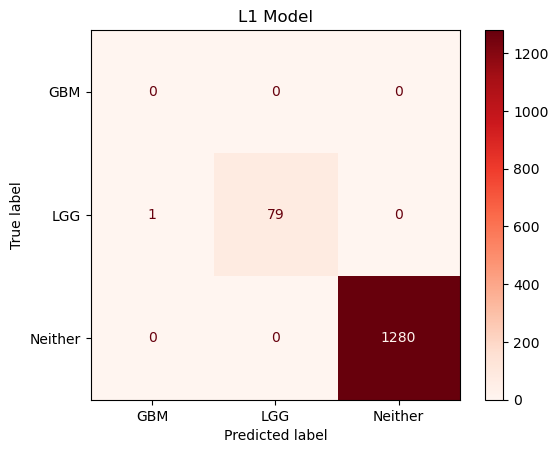  | 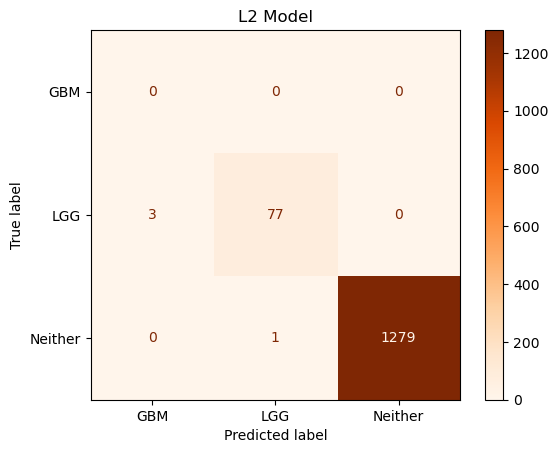  | 
| L1 Accuracy: 0.9992647058823529   | L2 Accuracy: 0.9970588235294118 | 


Both types fo regularization did improve the Validation accuracy from 99.56% to 99.92% and 99.71% for L1 and L2 respectively. We decided to go forth with L1 on the Test Data since it had a higher accuracy. We predict L1 was better because it does a good job and selecting the best features (in our case finding which genes drive LGG and GBM). As oppsed to L2 which filters everything. Essentially, L1 is best at filtering which is relevant here as we want genes that best express the glioma cancers. 

### Model Performance on Test Data

We found that unlike the validation dataset, the test data actually had GBM samples, so we produced a matrix and sample errors for both 2 class and 3 class scenario since we expanded our research question to include the prediction on non-glioma cancers.

#### Prepping Test Data for 2 and 3 Classes

In [24]:

# this code block loads the test data and metadata, creates the same 3-class label for the test metadata, subsets the test data to just the genes in the gene list

test_data = pd.read_csv(
    r'C:\Users\Asma Sanaullah\OneDrive - University of Virginia\Spring 2026\COMP BME\Module-4-Cancer\data\TEST_SET_GSE62944_subsample_log2TPM.csv',
    index_col=0
)

test_metadata = pd.read_csv(
    r'C:\Users\Asma Sanaullah\OneDrive - University of Virginia\Spring 2026\COMP BME\Module-4-Cancer\data\TEST_SET_GSE62944_metadata.csv',
    index_col=0
)


#%%

# this code block creates a subset of the test data for 2 class classification (GBM vs LGG), then merges it with the metadata for those samples

test_samples_2c = test_metadata[
    test_metadata["cancer_type"].isin(["GBM","LGG"])
].index

test_2c = test_data[test_samples_2c]
test_gene_2c = test_2c.loc[gene_list]

test_merged_2c = test_gene_2c.T.merge(
    test_metadata.loc[test_samples_2c],
    left_index=True,
    right_index=True
)

X_test_2c = test_merged_2c[gene_list]
y_test_2c = test_merged_2c["cancer_type"]



#%%

# this code block creates a new class label in the test metadata for a 3-class classification problem (GBM, LGG, Neither), then merges the full gene data with the metadata for all test samples

test_metadata["class_label"] = test_metadata["cancer_type"].apply(
    lambda x: x if x in ["GBM","LGG"] else "Neither"
)

test_3c = test_data[test_metadata.index]
test_gene_3c = test_3c.loc[gene_list]

test_merged_3c = test_gene_3c.T.merge(
    test_metadata,
    left_index=True,
    right_index=True
)

X_test_3c = test_merged_3c[gene_list]
y_test_3c = test_merged_3c["class_label"]

#### Testing 2 Class LGG & GBM

2-Class Test Accuracy: 0.96875
Out-of-Sample Error (2-Class Test Accuracy): 0.0312


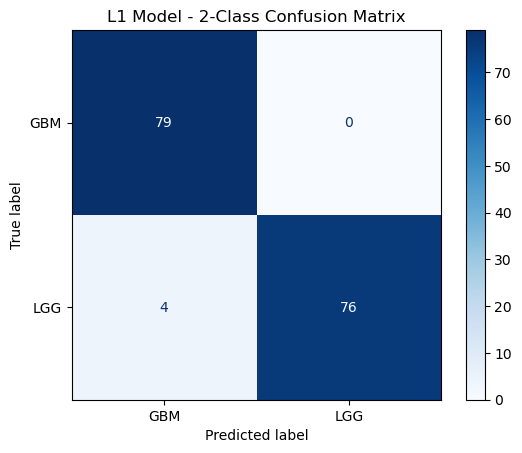

In [29]:
# this code block evaluates the L1 regularized logistic regression model on the 2-class test set, calculates accuracy, and creates a confusion matrix

y_pred_2c = model_l1.predict(X_test_2c) # 
acc_2c = accuracy_score(y_test_2c, y_pred_2c)
print("2-Class Test Accuracy:", acc_2c)
out_of_sample_error_2c = 1 - acc_2c
print(f"Out-of-Sample Error (2-Class Test Accuracy): {out_of_sample_error_2c:.4f}")
cm_2c = confusion_matrix(y_test_2c, y_pred_2c, labels=["GBM", "LGG"])
ConfusionMatrixDisplay(
    confusion_matrix=cm_2c,
    display_labels=["GBM", "LGG"]
).plot(cmap="Blues")
plt.title("L1 Model - 2-Class Confusion Matrix")
plt.show()

#### Testing 3 Classes - LGG, GBM & Neither

3-Class Test Accuracy: 0.996875
Out-of-Sample Error (3-Class Test Accuracy): 0.0031


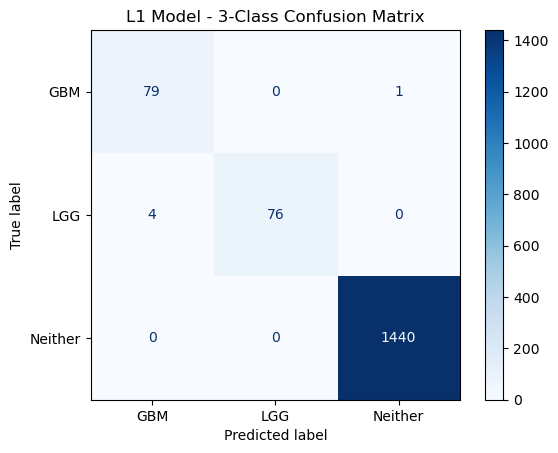

In [30]:
y_pred_3c = model_l1.predict(X_test_3c)
acc_3c = accuracy_score(y_test_3c, y_pred_3c)
print("3-Class Test Accuracy:", acc_3c)
out_of_sample_error_3c = 1 - acc_3c
print(f"Out-of-Sample Error (3-Class Test Accuracy): {out_of_sample_error_3c:.4f}")
cm_3c = confusion_matrix(
    y_test_3c,
    y_pred_3c,
    labels=["GBM", "LGG", "Neither"]
)
ConfusionMatrixDisplay(
    confusion_matrix=cm_3c,
    display_labels=["GBM", "LGG", "Neither"]
).plot(cmap="Blues")
plt.title("L1 Model - 3-Class Confusion Matrix")
plt.show()

#### Results for 3 Classes

| 2 Classes LGG & GBM | 3 Classes LGG, GBM & NEITHER| 
| -------- | -------- | 
| 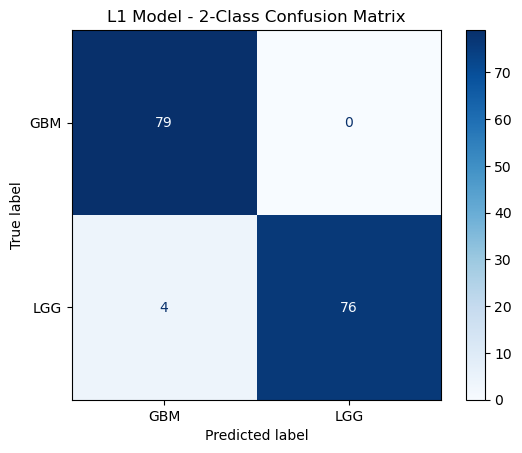   | 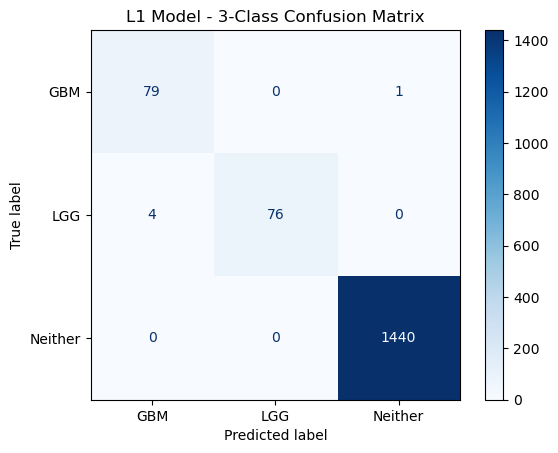  | 
| Accuracy: 0.96875  | Accuracy: 0.996875  | 
| Out-of-Sample Error: 0.0312 |Out-of-Sample Error: 0.0031 |


To see if we could improve the accuracy and error for 2 Classes, we tried L2 regularization. 

2-Class Test Accuracy: 0.98125
Out-of-Sample Error (2-Class Test Accuracy): 0.0188


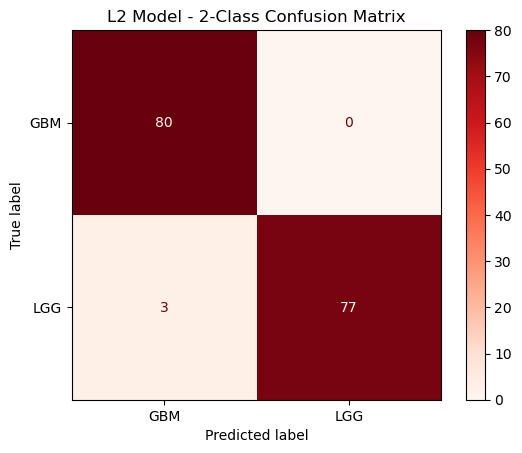

In [32]:
# this code block evaluates the L2 regularized logistic regression model on the 2-class test set, calculates accuracy, and creates a confusion matrix

y_pred_2c = model_l2.predict(X_test_2c)

acc_2c = accuracy_score(y_test_2c, y_pred_2c)
print("2-Class Test Accuracy:", acc_2c)

out_of_sample_error_2c = 1 - acc_2c
print(f"Out-of-Sample Error (2-Class Test Accuracy): {out_of_sample_error_2c:.4f}")

cm_2c = confusion_matrix(y_test_2c, y_pred_2c, labels=["GBM", "LGG"])

ConfusionMatrixDisplay(
    confusion_matrix=cm_2c,
    display_labels=["GBM", "LGG"]
).plot(cmap="Reds")

plt.title("L2 Model - 2-Class Confusion Matrix")
plt.show()

We did find that L2 performed better on the 2 Classes. Here is the comparision

| L1 | L2| 
| -------- | -------- | 
| 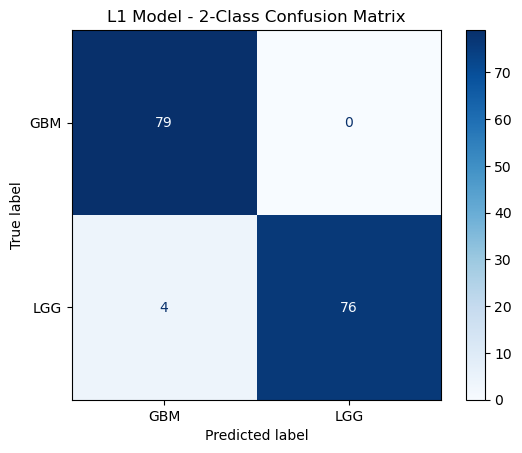  | 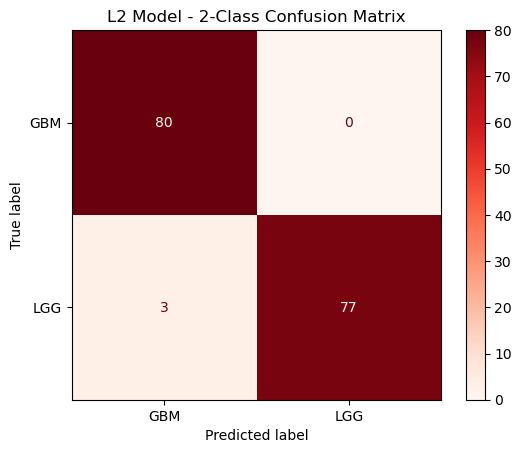  | 
| Accuracy: 0.96875  | Accuracy: 0.98125  | 
| Out-of-Sample Error: 0.0312 |Out-of-Sample Error: 0.0188 |



L2 regularization performed better in the binary classification, which implies that this class separation is based on a signal across many features. For the multilclassification, L1 performed because it may have been better and focusing on features where there is a clear difference with the third class, non-glioma cancers. Comparing 2 glioma cancers is harder than comparing glioma and non-glioma cancers. So different regularization terms were needed for both scenarios. 

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Citations
Dataset
https://pubmed.ncbi.nlm.nih.gov/26209429/

Bibliography for Disease Background: 

https://www.ncbi.nlm.nih.gov/books/NBK558954/#:~:text=GBM%20remains%20an%20incurable%20disease,gliosarcoma%2C%20and%20epithelioid%20cell%20subtypes
https://www.ncbi.nlm.nih.gov/books/NBK470003/#:~:text=Abstract,have%20been%20investigated%20in%20GBM
https://pmc.ncbi.nlm.nih.gov/articles/PMC10002587/#:~:text=The%20limit%20value%20for%20the,environmental%20factor%2C%20compared%20to%20RF
https://cms.nucleusnetwork.com/urban-beat/glioblastoma-incidence-rate-by-age-demographics-1767646805#:~:text=The%20incidence%20rate%20of%20glioblastoma%20begins%20to%20increase%20more%20significantly,by%20radiation%20therapy%20and%20chemotherapy
https://www.ispor.org/heor-resources/presentations-database/presentation/ispor-22nd-annual-international-meeting/a-real-world-claims-analysis-of-glioblastoma-cost-of-care-in-the-united-states 

## NOTES FROM YOUR TEAM: 
*This is where our team is taking notes and recording activity.*

## QUESTIONS FOR YOUR TA: 
*These are questions we have for our TA.*